# 📚 Student Productivity Prediction

## Day 005 - 100 Days of Machine Learning

## 🎯 Objective

The objective of this project is to predict student productivity using various academic, lifestyle, and behavioral features.

This project demonstrates a complete machine learning regression workflow, covering data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, and model evaluation.

## 📚 Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## 📂 Load Dataset

In [3]:
df = pd.read_csv('Data/Student_Productivity_Dataset.csv')

## 🔍 Dataset Overview

In [4]:
df.shape

(10000, 20)

In [5]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day',
       'Sleep_Hours_Per_Night', 'Screen_Time_Hours', 'Social_Media_Hours',
       'Attendance_Percentage', 'Assignments_Completed',
       'Class_Participation_Score', 'Physical_Activity_Hours_Per_Week',
       'Stress_Level', 'Motivation_Level', 'Internet_Quality', 'Part_Time_Job',
       'Extracurricular_Involvement', 'AI_Tool_Usage_Hours_Per_Week',
       'Previous_Semester_GPA', 'Productivity_Score', 'Performance_Category'],
      dtype='str')

In [6]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   str    
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motivation_Level

In [8]:
df.describe()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,10000.00000,9845.000000,9835.000000,9894.000000,9868.000000,9920.000000,9878.000000,9882.000000,9815.000000,9863.000000,9846.000000,9825.000000,9822.000000,9860.000000,9839.000000,10000.000000
mean,5000.50000,20.134891,4.219583,6.976602,6.047862,3.032107,79.817301,74.251872,5.991218,3.200862,5.542840,5.957924,4.050204,5.544726,6.489753,54.607333
std,2886.89568,2.497517,1.950639,1.303614,2.424031,1.729774,12.348369,16.588029,2.150297,2.252450,2.107599,2.111982,2.367947,3.892723,1.580462,12.340640
min,1.00000,16.000000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.000000,2.800000,6.100000,4.300000,1.800000,71.200000,62.900000,4.500000,1.600000,4.100000,4.500000,2.300000,2.700000,5.415000,46.640000
50%,5000.50000,20.000000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,7500.25000,22.000000,5.600000,7.900000,7.700000,4.200000,89.100000,86.800000,7.500000,4.300000,7.000000,7.400000,5.700000,7.500000,7.590000,63.032500
max,10000.00000,25.000000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


In [9]:
df.isnull().sum()

Student_ID                            0
Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
Productivity_Score                    0
Performance_Category                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## 📊 Exploratory Data Analysis (EDA)



In [11]:
df.drop(['Student_ID'],axis=1,inplace=True) 

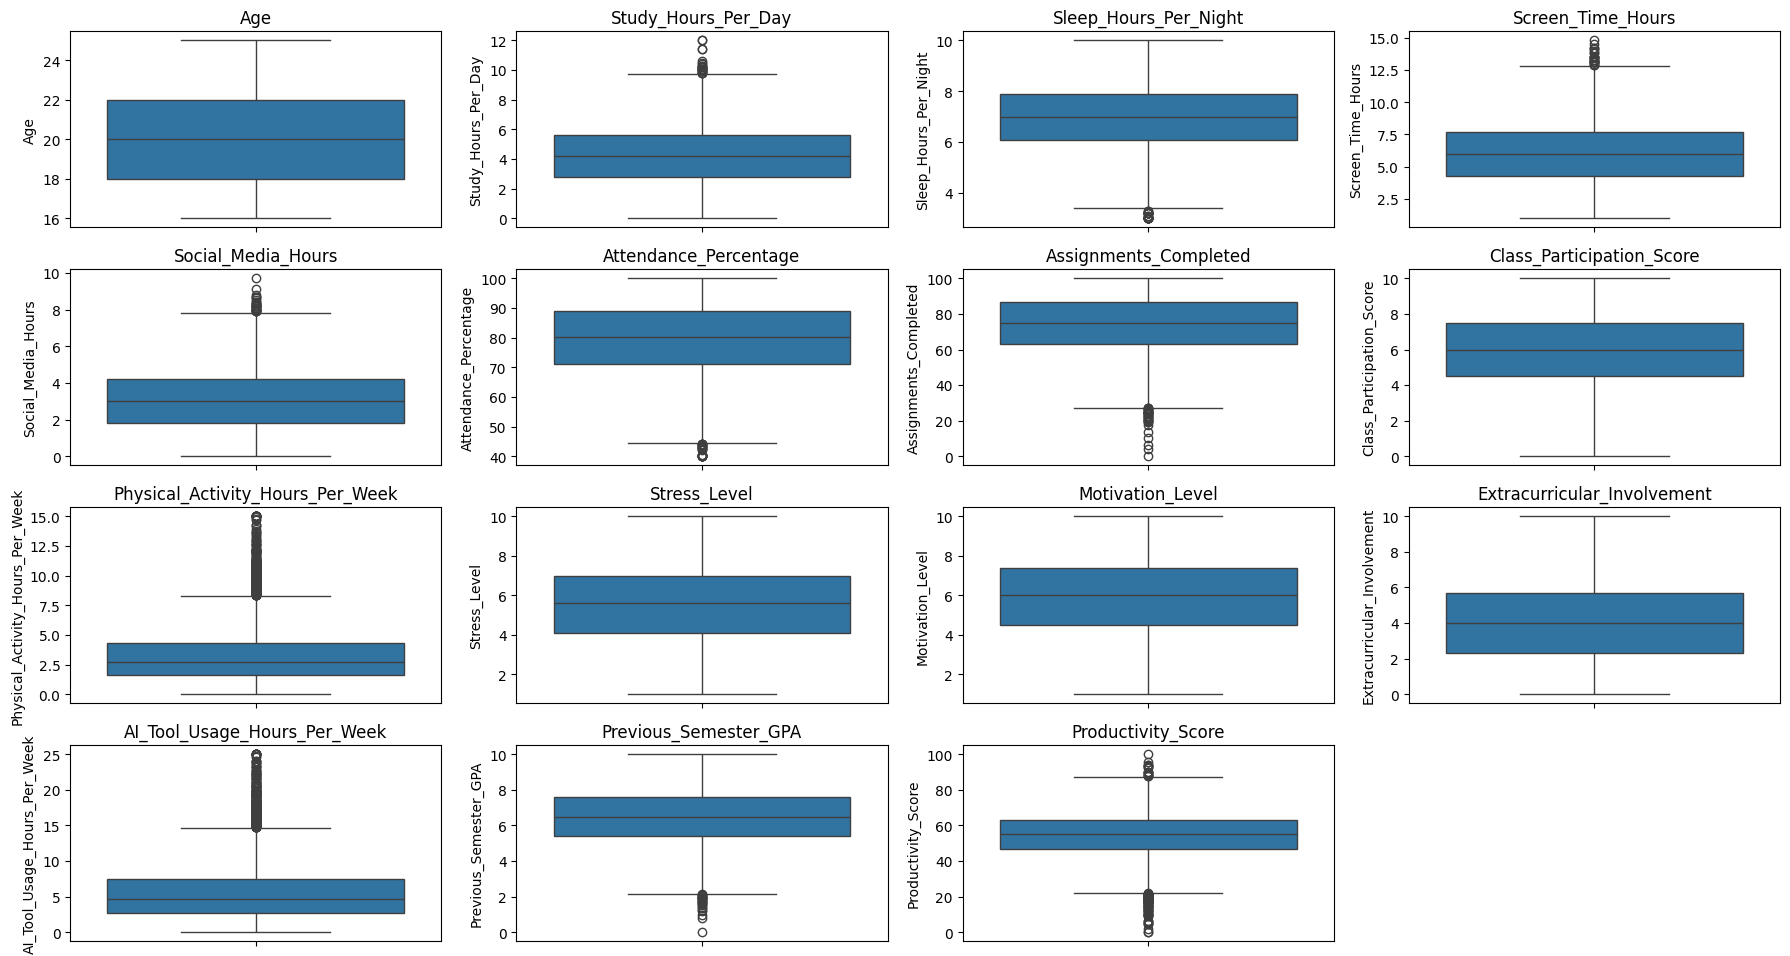

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

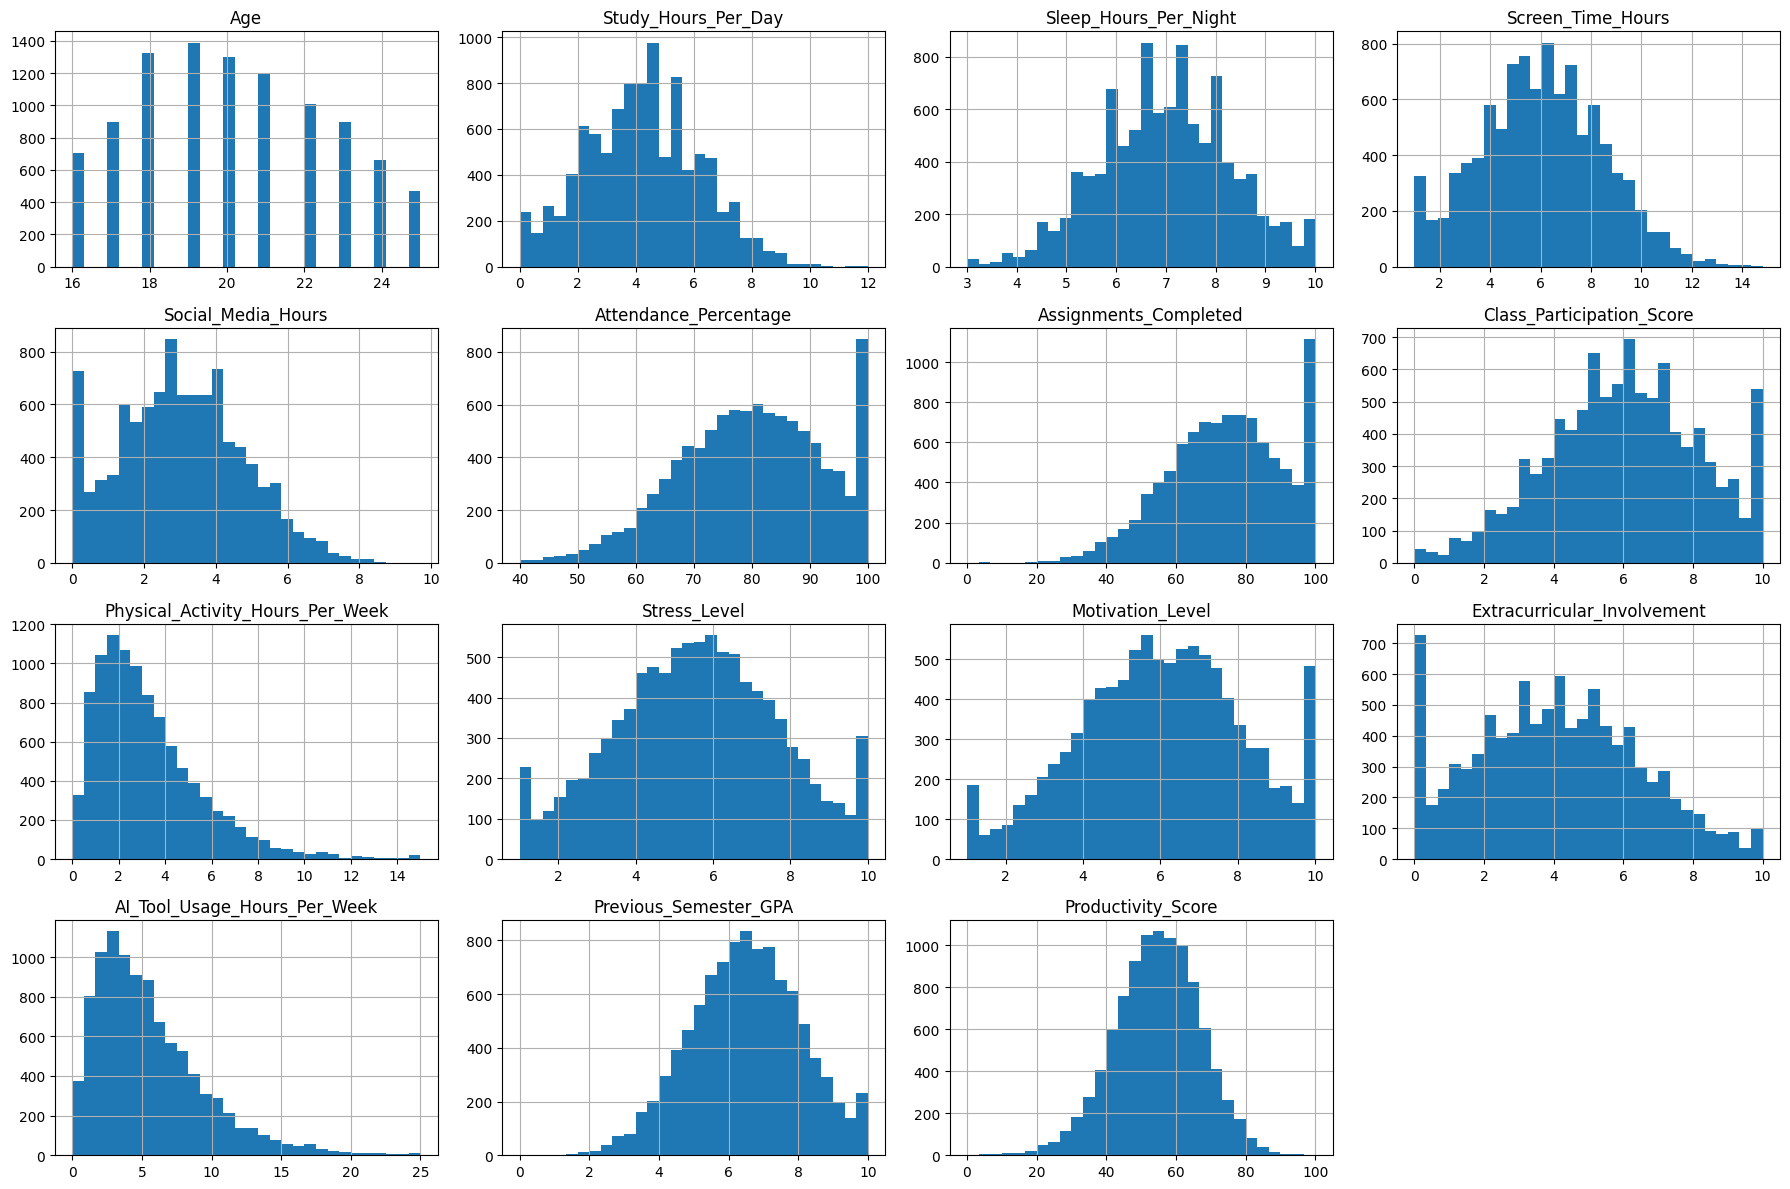

In [13]:
df[num_cols].hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

<Axes: >

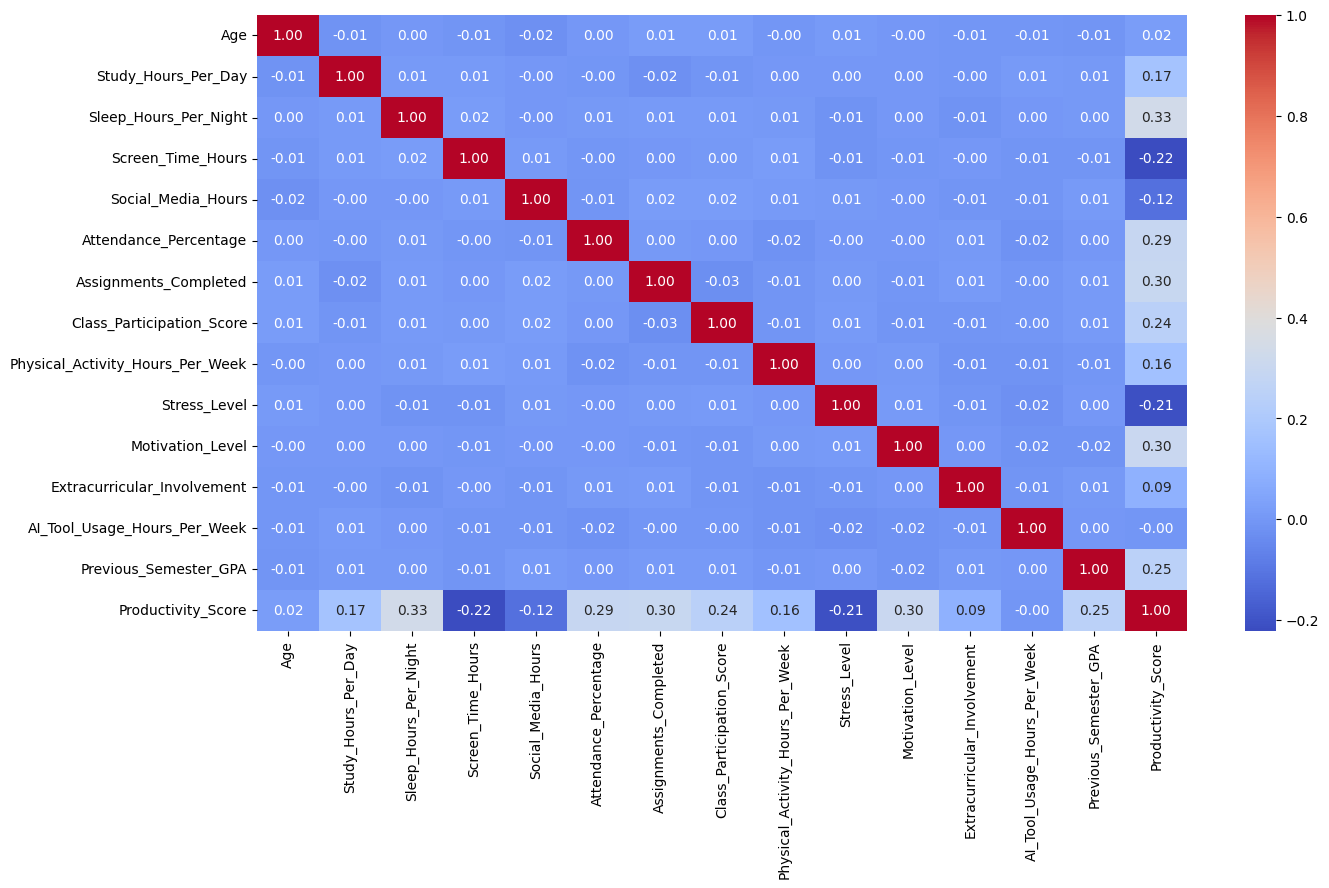

In [18]:
num_values= df.select_dtypes(include='number')
corr_matrix=num_values.corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')

## 🧹 Data Cleaning

In [14]:
mean_cols=['Age','Class_Participation_Score','Stress_Level','Motivation_Level','Extracurricular_Involvement']
median_cols=['Study_Hours_Per_Day','Sleep_Hours_Per_Night','Screen_Time_Hours','Social_Media_Hours','Attendance_Percentage','Assignments_Completed','Physical_Activity_Hours_Per_Week','AI_Tool_Usage_Hours_Per_Week','Previous_Semester_GPA']
cat_cols=['Gender','Internet_Quality','Part_Time_Job']

In [15]:
for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
df.isnull().sum()

Age                                 0
Gender                              0
Study_Hours_Per_Day                 0
Sleep_Hours_Per_Night               0
Screen_Time_Hours                   0
Social_Media_Hours                  0
Attendance_Percentage               0
Assignments_Completed               0
Class_Participation_Score           0
Physical_Activity_Hours_Per_Week    0
Stress_Level                        0
Motivation_Level                    0
Internet_Quality                    0
Part_Time_Job                       0
Extracurricular_Involvement         0
AI_Tool_Usage_Hours_Per_Week        0
Previous_Semester_GPA               0
Productivity_Score                  0
Performance_Category                0
dtype: int64

## 🔄 Feature Scaling

In [19]:
X = df.drop("Productivity_Score", axis=1)
y = df["Productivity_Score"]

In [26]:
cat_cols = X.select_dtypes(include="object").columns

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore",drop='first'),
            cat_cols
        )
    ],
    remainder="passthrough"
)


## ✂️ Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [29]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## 🤖 Model Training &  🎛 Hyperparameter Tuning


In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores.mean())

0.8518230756769934


In [32]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", root_mean_squared_error(y_test, y_pred_lr))

R²: 0.8598545307627069
MAE: 3.641859539683935
RMSE: 4.56883929422517


In [47]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge.fit(X_train, y_train)

print(ridge.alpha_) 

0.1


In [34]:
y_pred_rc = ridge.predict(X_test)

print("R²:", r2_score(y_test, y_pred_rc))
print("MAE:", mean_absolute_error(y_test, y_pred_rc))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rc))

R²: 0.8598538139920864
MAE: 3.6417832723858896
RMSE: 4.56885097781939


In [35]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    alphas=[0.001, 0.01, 0.1, 1, 10],
    cv=5,
    random_state=42
)

lasso.fit(X_train, y_train)

print("Best alpha:", lasso.alpha_)

Best alpha: 0.01


In [36]:
y_pred_lc = lasso.predict(X_test)

print("R²:", r2_score(y_test, y_pred_lc))
print("MAE:", mean_absolute_error(y_test, y_pred_lc))
print("RMSE:", root_mean_squared_error(y_test, y_pred_lc))

R²: 0.8598654994804429
MAE: 3.638288629512264
RMSE: 4.568660496831718


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10,20,40],
    "min_samples_leaf": [1, 2, 4],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Params: {'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV R²: 0.8119768284902011


In [40]:
best_dt = grid.best_estimator_

y_pred_tree = best_dt.predict(X_test)

print("R²:", r2_score(y_test, y_pred_tree))
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", root_mean_squared_error(y_test, y_pred_tree))

R²: 0.8099840449100428
MAE: 4.253992776726422
RMSE: 5.319996980177513


In [41]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30, 
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Best CV R²: 0.8556316568998916


In [42]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.8597893017681022
MAE: 3.63366337036654
RMSE: 4.569902425719285


In [43]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Best Params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV R²: 0.8835063813505881


In [44]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.8824600567199181
MAE: 3.3614693521499635
RMSE: 4.184167768674588


# ✅ Conclusion

This project implemented a complete machine learning regression pipeline to predict **student productivity**. Multiple regression models were trained, compared, and evaluated using **R² Score**, **Mean Absolute Error (MAE)**, and **Root Mean Squared Error (RMSE)**.

---

# 📊 Model Performance Summary

| Rank | Model | R² ↑ | MAE ↓ | RMSE ↓ | Remarks |
|------|-----------------------|---------:|---------:|---------:|--------------------------------|
| 🥇 1 | **XGBoost (Tuned)** | **0.8825** | **3.3615** | **4.1842** | Best overall model |
| 🥈 2 | LassoCV | 0.8599 | 3.6383 | 4.5687 | Best linear model |
| 🥉 3 | Linear Regression | 0.8599 | 3.6419 | 4.5688 | Strong baseline |
| 4 | RidgeCV | 0.8599 | 3.6418 | 4.5689 | Similar to Linear Regression |
| 5 | Random Forest (Tuned) | 0.8598 | 3.6337 | 4.5699 | Comparable performance but more complex |
| 6 | XGBoost (Default) | 0.8595 | 3.6375 | 4.5754 | Hyperparameter tuning significantly improved performance |
| 7 | Decision Tree (Tuned) | 0.8100 | 4.2540 | 5.3200 | Lowest-performing model |

---

# 🏆 Best Performing Model

🥇 **XGBoost Regressor (Tuned)**

### 📈 Performance

- **R² Score:** **0.8825**
- **MAE:** **3.3615**
- **RMSE:** **4.1842**

### ⭐ Why did it perform the best?

- Achieved the **highest R² Score (88.25%)**, explaining the largest proportion of variance in student productivity.
- Produced the **lowest MAE**, indicating the smallest average prediction error.
- Recorded the **lowest RMSE**, demonstrating the best overall predictive accuracy.
- Hyperparameter tuning significantly improved its performance over the default XGBoost model.
- Successfully captured the non-linear relationships present in the dataset, outperforming both linear and tree-based regression models.

---

# 🎯 Key Learning Outcomes

- Data preprocessing and cleaning
- Missing value handling
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression model comparison
- Hyperparameter tuning using GridSearchCV
- Cross-validation
- Model evaluation using R² Score, MAE, and RMSE